# Single Backtest Runner

This notebook orchestrates a single backtest run for the `ggTrader` engine. It supports flexible symbol selection (direct list or JSON file) and provides basic performance visualization.

In [6]:
import sys
import os
import pandas as pd
import numpy as np
import vectorbt as vbt
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Ensure project root is in path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'src'))
if project_root not in sys.path:
    sys.path.append(project_root)

from ggTrader.utils.setup import load_data_and_setup
from ggTrader.core.trading import Trading
from ggTrader.utils.results_manager import ResultsManager

print("Environment initialized.")

Environment initialized.


In [7]:
# --- Configuration ---
CONSTANTS = {
    "SYMBOLS": None,  # Set to None to use SYMBOLS_FILE
    "SYMBOLS_FILE": os.path.join(project_root, "..", "data", "top_20_consistent_movers.json"),
    "INTERVAL": "4h",
    "START_DATE": "2024-01-01",
    "END_DATE": "2025-06-01",
    "START_CASH": 10000,
    "PORTFOLIO_SHARE": 0.20,
    "DEFAULT_PARAMS": {
        "adx_threshold": 25,
        "adx_length": 14,
        "sar_acceleration": 0.02,
        "sar_maximum": 0.2,
        "atr_multiplier": 3.0,
        "atr_length": 14,
        "use_dmp_cross": False,
    }
}

print("Configuration loaded.")

Configuration loaded.


In [8]:
print("Loading data...")
try:
    ohlcv = load_data_and_setup(CONSTANTS)
    print(f"Loaded {len(ohlcv)} rows for {len(ohlcv.columns.levels[0])} symbols.")
except Exception as e:
    print(f"Error loading data: {e}")

Loading data...
Error loading data: 'NoneType' object is not iterable


In [9]:
print("Running backtest...")
engine = Trading(
    ohlcv_df=ohlcv,
    date_range=ohlcv.index,
    start_cash=CONSTANTS["START_CASH"],
    max_position=CONSTANTS["PORTFOLIO_SHARE"],
    strategy_params=CONSTANTS["DEFAULT_PARAMS"],
)
engine.run()
print("Backtest complete.")

Running backtest...


Backtest complete.


Processing results...

--- Performance Summary ---
cash: 3083.9813
total_position_value: 4544.0671
total_value: 7628.0485
realized_profit: -2345.7745
unrealized_profit: -26.1770
total_profit: -2371.9515
profit_pct: -23.7195
transaction_fee_total: 3733.3987
total_trades: 248
sharpe: -0.8238
sortino: -0.9860
max_drawdown: 0.4623
max_drawdown_pct: 46.2296
---------------------------


C:\Users\gkuep\AppData\Local\Temp\ipykernel_8200\2143054031.py:10: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



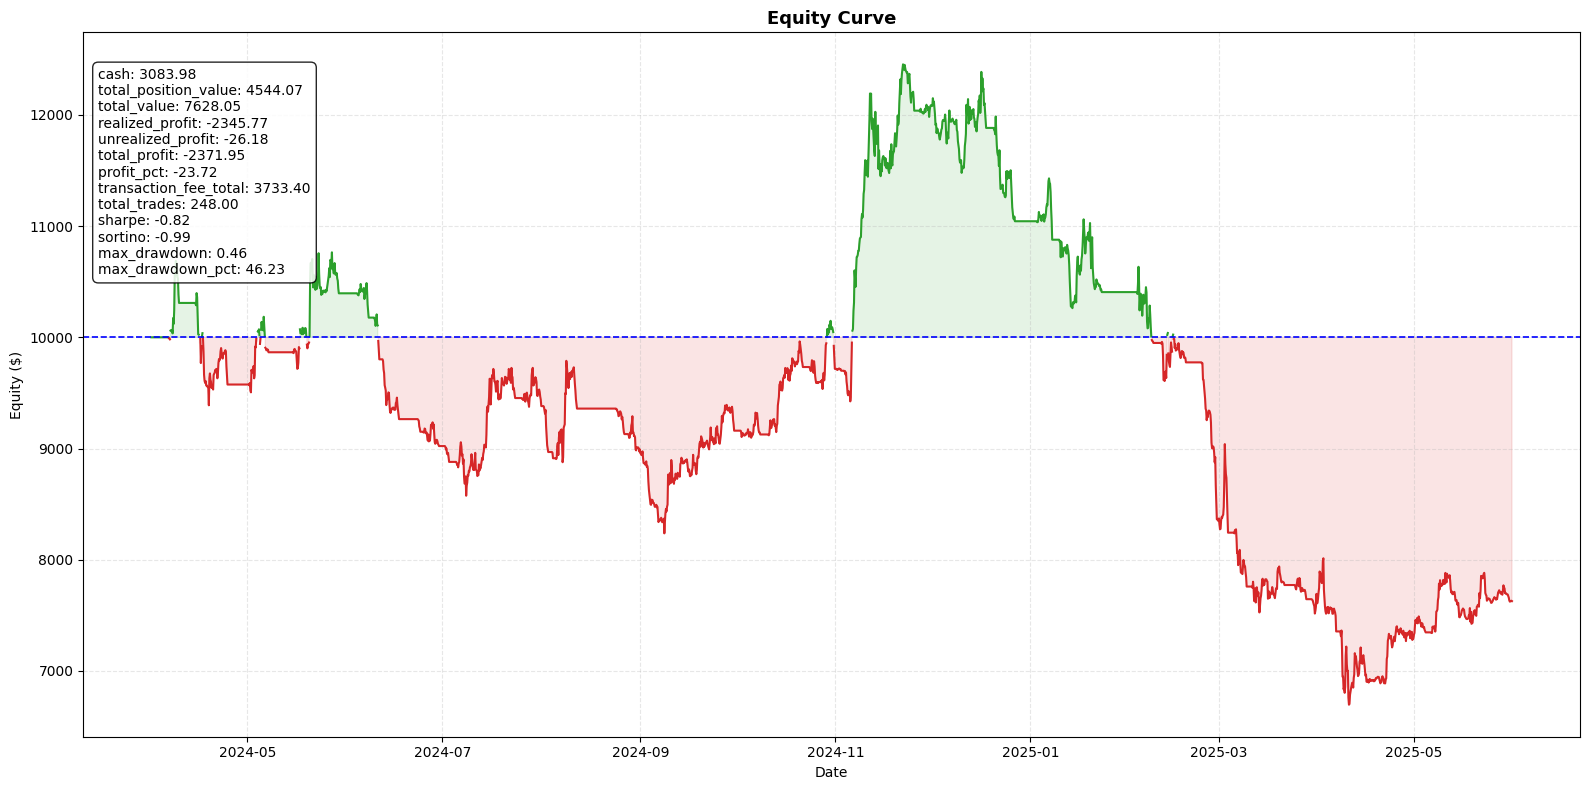

In [10]:
print("Processing results...")
stats = engine.portfolio.stats_dict()
rm = ResultsManager("notebook_runner")

# Print summary
rm.print_summary(stats)

# Plot Equity Curve
fig = engine.portfolio.plot_value()
fig.show()